# Association Rules Mining - Khai Phá Luật Kết Hợp

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from mlxtend.frequent_patterns import fpgrowth, association_rules
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent
INPUT_PATH = BASE_DIR / "outputs" / "data_split" / "train.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "association"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load và Khám Phá Dữ Liệu

In [3]:
start_time = time.time()

# Đọc dữ liệu
df = pd.read_csv(INPUT_PATH)

print(f"📊 Tổng số interactions: {len(df):,}")
print(f"👥 Số users: {df['user_id'].nunique():,}")
print(f"🎬 Số movies: {df['movie_title'].nunique():,}")
print(f"\n⭐ Phân phối rating:")
print(df['rating'].describe())

📊 Tổng số interactions: 6,862
👥 Số users: 2,454
🎬 Số movies: 1,859

⭐ Phân phối rating:
count    6862.000000
mean        6.287380
std         2.485794
min         1.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        10.000000
Name: rating, dtype: float64


In [4]:
# Hiển thị mẫu dữ liệu
df.head()

,user_id,movie_id,movie_title,rating,cast,release_year,language,genres_list,primary_genre,genre_count,...,genre_thriller,genre_tv_movie,genre_war,genre_western,primary_genre_encoded,user_idx,movie_idx,source_encoded,year_scaled,genre_count_scaled
0,Sejian,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,779,741,0,1.0,0.333333
1,MovieGuys,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,600,741,0,1.0,0.333333
2,Dean,1265609,War Machine,9.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,248,741,0,1.0,0.333333
3,MovieGuys,1290821,Shelter,6.0,"Jason Statham, Bodhi Rae Breathnach, Michael S...",2026,en,"[""action"", ""crime"", ""thriller""]",action,3,...,1,0,0,0,0,600,797,0,1.0,0.333333
4,Kashifzia,799882,The Bluff,6.0,"Priyanka Chopra Jonas, Karl Urban, Safia Oakle...",2026,en,"[""action"", ""thriller""]",action,2,...,1,0,0,0,0,473,2283,0,1.0,0.166667


## 3. Lọc Phim Được Đánh Giá Cao

Chỉ lấy các phim có rating >= 7.0 để tìm các mẫu phim tốt thường được xem cùng nhau.

In [5]:
# Lọc phim rating cao
high_rated = df[df['rating'] >= 7.0].copy()

print(f"📊 Số interactions rating cao (>= 7.0): {len(high_rated):,}")
print(f"   Tỷ lệ: {len(high_rated)/len(df)*100:.1f}%")
print(f"\n👥 Số users có rating cao: {high_rated['user_id'].nunique():,}")
print(f"🎬 Số movies được rating cao: {high_rated['movie_title'].nunique():,}")

📊 Số interactions rating cao (>= 7.0): 3,616
   Tỷ lệ: 52.7%

👥 Số users có rating cao: 1,178
🎬 Số movies được rating cao: 1,438


## 4. Tạo Transaction Matrix

Chuyển đổi dữ liệu thành ma trận nhị phân (user-movie) cho FP-Growth.

In [6]:
# Tạo basket (transaction matrix)
basket = (high_rated.groupby(['user_id', 'movie_title'])['rating']
          .count().unstack().reset_index().fillna(0)
          .set_index('user_id'))

print(f"📊 Basket shape: {basket.shape}")
print(f"   {basket.shape[0]} users x {basket.shape[1]} movies")

📊 Basket shape: (1178, 1438)
   1178 users x 1438 movies


In [7]:
# Convert sang boolean
basket_sets = basket.map(lambda x: 1 if x > 0 else 0).astype(bool)

print("✅ Transaction matrix đã được tạo")
basket_sets.head()

✅ Transaction matrix đã được tạo


movie_title,"""Wuthering Heights""",(500) Days of Summer,10 Things I Hate About You,12 Angry Men,12 Hours in October,12 Strong,12 Years a Slave,127 Hours,17 Again,20 Million Miles to Earth,...,Your Host,Z-O-M-B-I-E-S 4: Dawn of the Vampires,Zack Snyder's Justice League,Zodiac,Zombieland,Zootopia,Zootopia 2,"tick, tick... BOOM!",undertone,Éiru
user_id,,,,,,,,,,,,,,,,,,,,,
-LBJ-,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
.,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
02ed4d803049e3e76f12c7b9a60248f2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
0w2k4xa0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
35antonio,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Chạy FP-Growth

Tìm các itemsets xuất hiện thường xuyên với min_support = 0.003.

In [8]:
# Chạy FP-Growth
print("🔍 Đang tìm frequent itemsets...")
frequent_itemsets = fpgrowth(basket_sets, min_support=0.003, use_colnames=True)

print(f"✅ Tìm thấy {len(frequent_itemsets)} frequent itemsets")
frequent_itemsets.head(10)

🔍 Đang tìm frequent itemsets...
✅ Tìm thấy 893 frequent itemsets


,support,itemsets
0,0.003396,"(""Wuthering Heights"")"
1,0.006791,(A Minecraft Movie)
2,0.003396,(Jurassic World Rebirth)
3,0.005093,(Alien³)
4,0.005093,(In the Blink of an Eye)
5,0.011036,(Final Destination Bloodlines)
6,0.003396,(Spider-Man: Homecoming)
7,0.005093,(Plainclothes)
8,0.005942,(The Housemaid)
9,0.005093,(Diablo)


In [9]:
# Phân tích itemsets theo độ dài
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("📊 Phân phối itemsets theo độ dài:")
print(frequent_itemsets['length'].value_counts().sort_index())

📊 Phân phối itemsets theo độ dài:
length
1    322
2    169
3    144
4    128
5     84
6     36
7      9
8      1
Name: count, dtype: int64


## 6. Khai Phá Luật Kết Hợp

Tạo association rules với lift >= 1.0.

In [10]:
# Khai phá luật
print("🔍 Đang khai phá association rules...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"✅ Tìm thấy {len(rules)} rules")
rules.head(10)

🔍 Đang khai phá association rules...
✅ Tìm thấy 9134 rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Alien³),(Alien),0.005093,0.006791,0.003396,0.666667,98.166667,1.0,0.003361,2.979626,0.994881,0.400000,0.664387,0.583333
1,(Alien),(Alien³),0.006791,0.005093,0.003396,0.500000,98.166667,1.0,0.003361,1.989813,0.996581,0.400000,0.497440,0.583333
2,(Alien³),(Aliens),0.005093,0.009338,0.003396,0.666667,71.393939,1.0,0.003348,2.971986,0.991041,0.307692,0.663525,0.515152
3,(Aliens),(Alien³),0.009338,0.005093,0.003396,0.363636,71.393939,1.0,0.003348,1.563425,0.995287,0.307692,0.360379,0.515152
4,"(Alien³, Aliens)",(Alien),0.003396,0.006791,0.003396,1.000000,147.250000,1.0,0.003373,inf,0.996593,0.500000,1.000000,0.750000
5,"(Alien, Aliens)",(Alien³),0.005093,0.005093,0.003396,0.666667,130.888889,1.0,0.003370,2.984720,0.997440,0.500000,0.664960,0.666667
6,"(Alien³, Alien)",(Aliens),0.003396,0.009338,0.003396,1.000000,107.090909,1.0,0.003364,inf,0.994037,0.363636,1.000000,0.681818
7,(Aliens),"(Alien³, Alien)",0.009338,0.003396,0.003396,0.363636,107.090909,1.0,0.003364,1.566093,1.000000,0.363636,0.361468,0.681818
8,(Alien³),"(Alien, Aliens)",0.005093,0.005093,0.003396,0.666667,130.888889,1.0,0.003370,2.984720,0.997440,0.500000,0.664960,0.666667
9,(Alien),"(Alien³, Aliens)",0.006791,0.003396,0.003396,0.500000,147.250000,1.0,0.003373,1.993209,1.000000,0.500000,0.498296,0.750000


## 7. Phân Tích Rules

In [11]:
# Thống kê metrics
print("📊 Thống kê Association Rules:")
print(f"\n   Support:")
print(f"      Min: {rules['support'].min():.4f}")
print(f"      Max: {rules['support'].max():.4f}")
print(f"      Mean: {rules['support'].mean():.4f}")

print(f"\n   Confidence:")
print(f"      Min: {rules['confidence'].min():.4f}")
print(f"      Max: {rules['confidence'].max():.4f}")
print(f"      Mean: {rules['confidence'].mean():.4f}")

print(f"\n   Lift:")
print(f"      Min: {rules['lift'].min():.4f}")
print(f"      Max: {rules['lift'].max():.4f}")
print(f"      Mean: {rules['lift'].mean():.4f}")

📊 Thống kê Association Rules:

   Support:
      Min: 0.0034
      Max: 0.0051
      Mean: 0.0034

   Confidence:
      Min: 0.3333
      Max: 1.0000
      Mean: 0.8835

   Lift:
      Min: 35.6970
      Max: 294.5000
      Mean: 228.4461


In [12]:
# Top 10 rules theo lift
top_rules = rules.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print("🏆 Top 10 Rules theo Lift:")
top_rules

🏆 Top 10 Rules theo Lift:


,antecedents,consequents,support,confidence,lift
70,"(Spider-Man: No Way Home, Captain America: The...",(Mission: Impossible - Dead Reckoning Part One...,0.003396,1.0,294.5
71,"(Spider-Man: No Way Home, Mission: Impossible ...","(Captain America: The Winter Soldier, The Batman)",0.003396,1.0,294.5
74,"(Captain America: The Winter Soldier, The Batman)","(Spider-Man: No Way Home, Mission: Impossible ...",0.003396,1.0,294.5
75,(Mission: Impossible - Dead Reckoning Part One...,"(Spider-Man: No Way Home, Captain America: The...",0.003396,1.0,294.5
103,"(Captain America: The Winter Soldier, Top Gun:...",(Mission: Impossible - Dead Reckoning Part One...,0.003396,1.0,294.5
104,"(Captain America: The Winter Soldier, The Batman)","(Top Gun: Maverick, Mission: Impossible - Dead...",0.003396,1.0,294.5
105,"(Top Gun: Maverick, Mission: Impossible - Dead...","(Captain America: The Winter Soldier, The Batman)",0.003396,1.0,294.5
106,(Mission: Impossible - Dead Reckoning Part One...,"(Captain America: The Winter Soldier, Top Gun:...",0.003396,1.0,294.5
130,"(Spider-Man: No Way Home, Captain America: The...","(Top Gun: Maverick, Mission: Impossible - Dead...",0.003396,1.0,294.5
131,"(Spider-Man: No Way Home, Mission: Impossible ...","(Captain America: The Winter Soldier, Top Gun:...",0.003396,1.0,294.5


## 8. Visualization

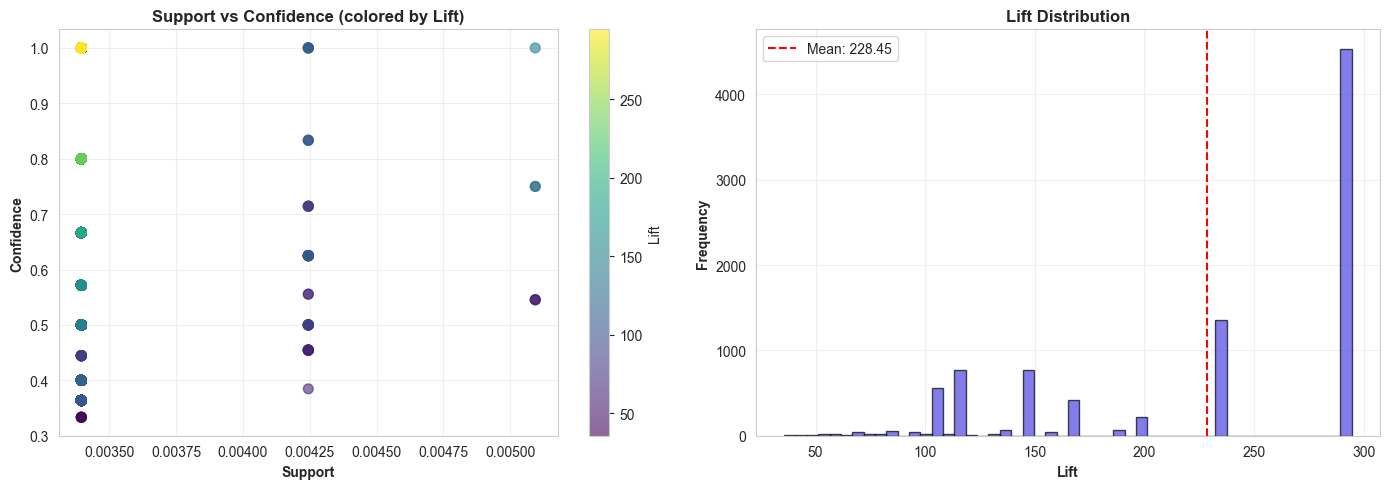

In [13]:
# Scatter plot: Support vs Confidence (colored by Lift)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Support vs Confidence
scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                         c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('Support', fontweight='bold')
axes[0].set_ylabel('Confidence', fontweight='bold')
axes[0].set_title('Support vs Confidence (colored by Lift)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].grid(alpha=0.3)

# Subplot 2: Lift distribution
axes[1].hist(rules['lift'], bins=50, color='#4f46e5', alpha=0.7, edgecolor='black')
axes[1].axvline(rules['lift'].mean(), color='red', linestyle='--', 
               label=f'Mean: {rules["lift"].mean():.2f}')
axes[1].set_xlabel('Lift', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Lift Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rules_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

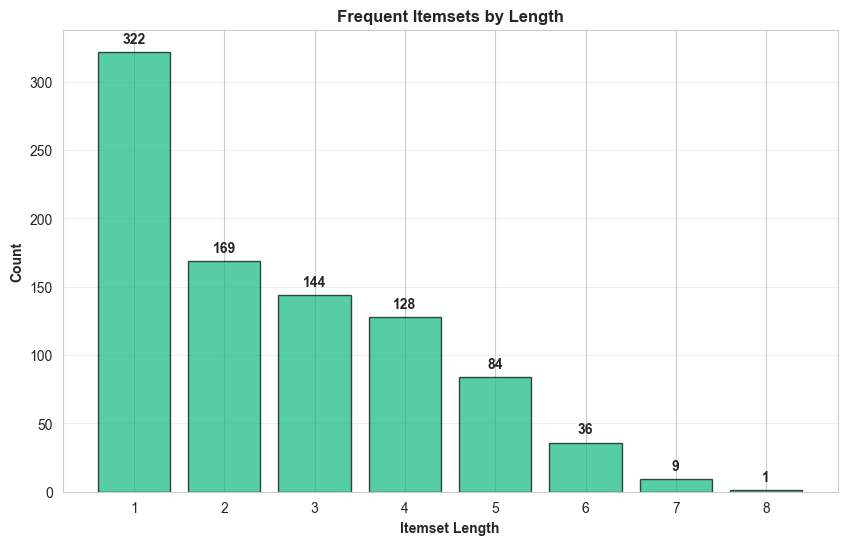

In [14]:
# Itemset length distribution
plt.figure(figsize=(10, 6))
length_counts = frequent_itemsets['length'].value_counts().sort_index()
plt.bar(length_counts.index, length_counts.values, color='#10b981', alpha=0.7, edgecolor='black')
plt.xlabel('Itemset Length', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Frequent Itemsets by Length', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(length_counts.values):
    plt.text(length_counts.index[i], v + max(length_counts.values)*0.02, 
            str(v), ha='center', fontweight='bold')

plt.savefig(OUTPUT_DIR / "itemsets_length.png", dpi=300, bbox_inches='tight')
plt.show()

## 9. Lưu Kết Quả

In [ ]:
# Xử lý rules để lưu Parquet
rules_save = rules.copy()
rules_save['antecedents'] = rules_save['antecedents'].apply(lambda x: list(x))
rules_save['consequents'] = rules_save['consequents'].apply(lambda x: list(x))
rules_save['antecedents_str'] = rules_save['antecedents'].astype(str)
rules_save['consequents_str'] = rules_save['consequents'].astype(str)

# Lưu Rules Parquet
rules_save.to_parquet(OUTPUT_DIR / "rules.parquet", engine='pyarrow', index=False)
print("✅ Đã lưu rules.parquet")

In [ ]:
# Lưu Itemsets Parquet
frequent_itemsets_save = frequent_itemsets.copy()
frequent_itemsets_save['itemsets'] = frequent_itemsets_save['itemsets'].apply(lambda x: list(x)).astype(str)
frequent_itemsets_save.to_parquet(OUTPUT_DIR / "itemsets.parquet", engine='pyarrow', index=False)
print("✅ Đã lưu itemsets.parquet")

In [ ]:
# Lưu Dictionary (Movie ID -> Title)
movie_dict = df[['movie_id', 'movie_title']].drop_duplicates().set_index('movie_id')['movie_title'].to_dict()
with open(OUTPUT_DIR / "dictionary.json", "w", encoding='utf-8') as f:
    json.dump(movie_dict, f, ensure_ascii=False, indent=4)

print("✅ Đã lưu dictionary.json")

In [ ]:
# Lưu Raw Metrics
end_time = time.time()
metrics = {
    "mining_time_seconds": round(end_time - start_time, 4),
    "num_rules": len(rules),
    "num_itemsets": len(frequent_itemsets),
    "avg_lift": float(rules['lift'].mean()) if len(rules) > 0 else 0,
    "avg_confidence": float(rules['confidence'].mean()) if len(rules) > 0 else 0,
    "avg_support": float(rules['support'].mean()) if len(rules) > 0 else 0
}

with open(OUTPUT_DIR / "raw_metrics.json", "w", encoding='utf-8') as f:
    json.dump(metrics, f, indent=4)

print("✅ Đã lưu raw_metrics.json")

In [ ]:
# Lưu CSV dự phòng
rules_save.to_csv(OUTPUT_DIR / "rules.csv", index=False)
print("✅ Đã lưu rules.csv")

## 10. Tổng Kết

Quá trình khai phá luật kết hợp đã hoàn thành:

- **Thuật toán**: FP-Growth
- **Số rules**: {len(rules)}
- **Số itemsets**: {len(frequent_itemsets)}
- **Lift trung bình**: {rules['lift'].mean():.2f}
- **Outputs**: rules.parquet, itemsets.parquet, dictionary.json, raw_metrics.json